In [6]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

from pathlib import Path

import Antenna_Desc_n_Plot as antenna

antenna_grill = None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=10, delta_phi_deg=90, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)


mode = "VACUUM" # "RADIAL_ONLY" or "FULL_2D" or "VACUUM"
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, mode, antenna_grill)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
In LHCoupling class: n_para: 0.0+0.0j, n_perp_p: 1.00e+00+0.00e+00j, n_perp_m: 1.00e+00+0.00e+00j
Waveguide Medium set to: VACUUM


In [7]:
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, _, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode)

mode: VACUUM
==== 
Lx_plasma: 2.00e-02m,   Lx_pml: 2.74e-03m,    Lx_tot: 2.27e-02m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 1.05e-01m
Lz_plasma: 7.00e-01m, Lz_pml: 1.40e-01m, Lz_tot: 9.80e-01m
==== 
n_∥: 0.0+0.0j,   λ_∥: 8.10e+04m 
n_⟂⁺:1.00+0.00j, λ_⟂⁺: 8.10e-02m 
n_⟂-:1.00+0.00j, λ_⟂⁻: 8.10e-02m
==== 
n_index_meshing: 1.00 
λ_meshing: 8.10e-02m 
maxh_plasma: 8.10e-03m
==== 
Lz_wall: 1.05e-01m 
Lz_source: 4.90e-01m
==== 
PPW_pml: 50.0 
Sx_norm:2.50e+00, maxh_pml_radial: 6.48e-04 
Sz_norm_max: 4.12e+00, maxh_pml_toroidal: 3.93e-04 
maxh_pml_corner: 3.36e-04
[DOMAIN 2D DEFINED AND GLUED]
[MESH GENERATED !]
==== 
#DoFs = 176492
--- Solving the 3D vector linear system ---
==== 
w_size_R: 1.2154e-01m,    w_size_T: 1.2154e+05m
Gamma_R (SWR) = 2.806e-02
Gamma_T (SWR) = 7.772e-01
==== 
Net Power Flow (W/m) => P_in: 6.3813e-02 | P_out_top: -3.4558e-02 
P_out_right: 4.8664e-02 | P_out_T_left: 4.8664e-02
type(P_ideal): <class 'numpy.float64'>
Sx_val: nan W/m^2
(Lz_source): 0.490 
P_idea

/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/solver_2DHcurl_1DH1.py:668: RuntimeWarning: invalid value encountered in scalar divide
  Ey_over_Ez_ratio = 1j * (self.D*(self.P - np.abs(self.n_perp_p)**2)) / (self.n_perp_p * self.n_para * (self.S - (self.n_para**2 + self.n_perp_p**2)))


In [8]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260623_092930
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260623_092930


--- Extracting 2D Wave Map ---
[run 2D E map]
Lx_plasma: 2.00e-02m, Lx_pml: 2.74e-03m, Lx_tot: 2.27e-02m
Lz_plasma: 7.00e-01m, Lz_pml: 1.40e-01m, Lz_tot: 9.80e-01m
params recover in run_2D_wave_map
  --> Pure Multithreaded C++ vectorized interpolation...
In LHCoupling class: n_para: 0.0+0.0j, n_perp_p: 1.00e+00+0.00e+00j, n_perp_m: 1.00e+00+0.00e+00j
Waveguide Medium set to: VACUUM
PP_run_n_save: n_para: 0.0+0.0j, n_perp_p: 1.00e+00+0.00e+00j, n_perp_m: 1.00e+00+0.00e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260623_092930/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui
key: x_target_R, type(key): <class 'str'>, val: 0.019
key: peak_z_R, type(key): <class 'str'>, val: 0.6037307307307307
key: window_size_radial, type(key): <class 'str'>, val: 0.12153748297297298
key: z_target_T, type(key): <class 'str'>, val: 0.6649999999999999
key: peak_x_T, type(key): <class 'str'>, val: 0.0198
key: window_size_toroidal, type(key)

/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/PP_Plot_and_Load.py:186: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=12, ncol=2, framealpha=0.9)


--- Plot saved to /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260623_092930/Ez_map.png ---


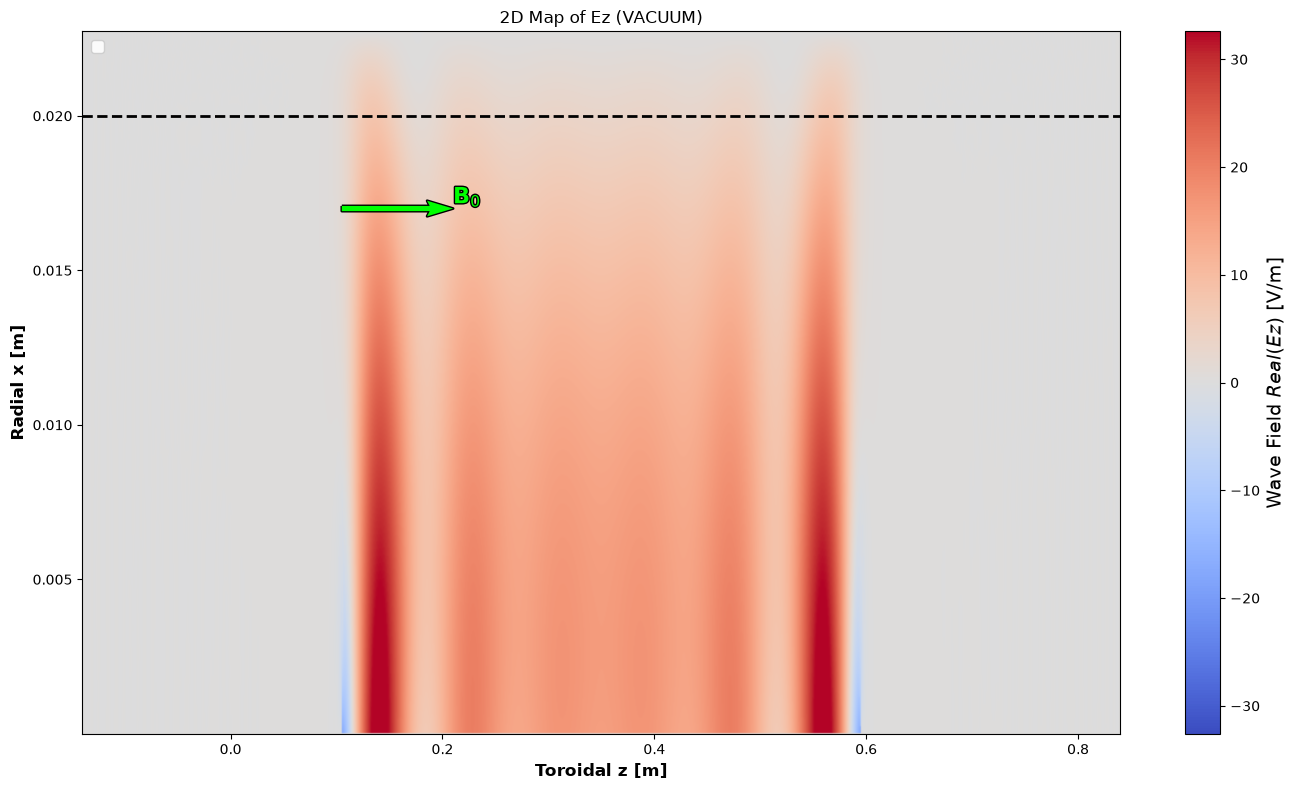

In [9]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, mode, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, mode, component='Ez', value_type='real',
                         antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=False, Poynting_box=False)

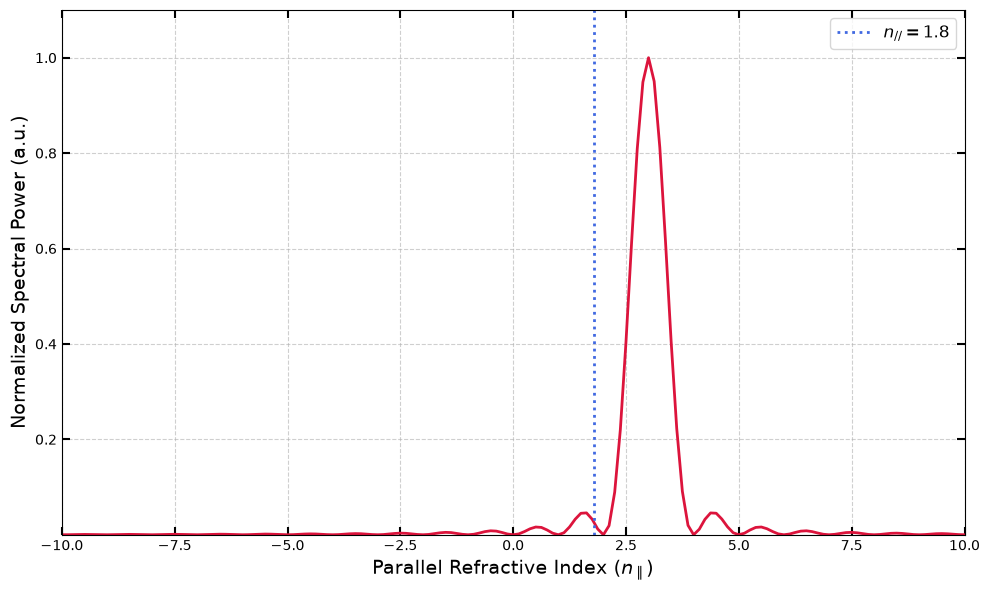

In [6]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, mode, x_eval=0.015)


In [ ]:
import os
import copy
import h5py
import numpy as np
import datetime
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def generate_1D_radial_pml_database(base_cfg, save_dir="Results"):
    """
    Exécute des balayages indépendants sur les paramètres de la PML Radiale
    pour plusieurs valeurs de n_parallel et sauvegarde dans un HDF5.
    """
    print("=========================================================")
    print("  GÉNÉRATION DATABASE : PML RADIALE 1D (JACQUOT 2013) ")
    print("=========================================================")
    
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    h5_filename = os.path.join(save_dir, f"PML_Radial_1D_Database_{timestamp}.h5")
    
    # 1. Les n_parallel à tester (Universalisme de la PML)
    n_para_list = [1.5, 2.0, 3.0, 5.0]
    
    # 2. Définition des balayages indépendants
    # Format -> 'Nom_du_Groupe': (Valeurs_à_tester, 'clé_PML')
    scans = {
        'Sweep_Sx_real': (np.linspace(0.5, 5.0, 20), 'Sx_r'),
        'Sweep_Sx_imag': (np.linspace(0.5, 12.0, 20), 'Sx_im'),
        'Sweep_px': (np.linspace(1.0, 5.0, 20), 'px'),
        'Sweep_Resolution_PPW': (np.linspace(10.0, 80.0, 15), 'ppw_pml'), # Contrôle maxh_pml
        'Sweep_Lpml_Ratio': (np.linspace(0.2, 3.5, 20), 'Lx_pml_ratio')   # L_pml / lambda_perp
    }
    
    with h5py.File(h5_filename, 'w') as h5f:
        h5f.attrs['Description'] = "Validation PML 1D Radiale (Onde Lente Backward)"
        
        for group_name, (param_values, param_key) in scans.items():
            print(f"\n---> Lancement du balayage : {group_name} ({param_key})")
            grp = h5f.create_group(group_name)
            grp.attrs['param_name'] = param_key
            grp.create_dataset('param_values', data=param_values)
            
            for n_para_val in n_para_list:
                print(f"  >> Test pour n_para = {n_para_val}")
                subgrp = grp.create_group(f"n_para_{n_para_val}")
                
                eta_sim_list, eta_pred_list = [], []
                Px_profiles, x_pml_coords = [], []
                for val in param_values:
                    # --- FIX: SAFE DEEPCOPY ---
                    # On ne copie que les dictionnaires purs (WAVE, DOMAIN, PML, etc.)
                    # et on ignore les modules importés (math, ngsolve) ou les variables système (__name__)
                    scan_cfg = {}
                    for key, value in base_cfg.items():
                        if isinstance(value, dict) and not key.startswith('__'):
                            scan_cfg[key] = copy.deepcopy(value)
                            
                    scan_cfg['WAVE']['n_para'] = n_para_val
                    
                    # Injection du paramètre
                    if param_key in ['Sx_r', 'Sx_im', 'px', 'ppw_pml']:
                        scan_cfg['PML'][param_key] = val
                    elif param_key == 'Lx_pml_ratio':
                        # Conversion du ratio en vraie distance physique L_pml
                        temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="RADIAL_ONLY", antenna_grill=None)
                        _, n_perp_p, _ = temp_solver.compute_physics_parameters()
                        lambda_perp = scan_cfg['WAVE']['lambda0'] / np.abs(n_perp_p.real)
                        scan_cfg['DOMAIN']['Lx_pml'] = val * lambda_perp
                        scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + scan_cfg['DOMAIN']['Lx_pml']
                        del temp_solver

                    try:
                        # On force antenna_grill=None pour une onde plane analytique pure
                        solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="RADIAL_ONLY", antenna_grill=None)
                        solver.build_physics_Stix_B_field()
                        mesh = solver.build_mesh_with_PMLs()
                        _, _, _, _, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode="RADIAL_ONLY")
                        
                        eta_sim_list.append(diag_data['eta_sim_R'])
                        eta_pred_list.append(diag_data['eta_pred_R'])
                        
                        # Profil Px et abscisse normalisée (x / lambda_perp) comme dans Jacquot
                        Px_profiles.append(diag_data['Px_pml_profile_norm'])
                        depth_norm = (diag_data['x_pml_sweep'] - scan_cfg['DOMAIN']['Lx_plasma']) / diag_data['lambda_perp_real']
                        x_pml_coords.append(depth_norm)
                        
                    except Exception as e:
                        print(f"     [!] Echec pour {param_key}={val:.3f} : {e}")
                        eta_sim_list.append(np.nan)
                        eta_pred_list.append(np.nan)
                
                # Sauvegarde dans le sous-groupe n_para
                subgrp.create_dataset('eta_sim', data=eta_sim_list)
                subgrp.create_dataset('eta_pred', data=eta_pred_list)
                if len(Px_profiles) > 0:
                    subgrp.create_dataset('Px_profiles', data=np.vstack(Px_profiles))
                    subgrp.create_dataset('x_normalized_depths', data=np.vstack(x_pml_coords))
                    
    print(f"\n[SUCCÈS] Base de données HDF5 générée : {h5_filename}")
    return h5_filename

db_filepath = generate_1D_radial_pml_database(cfg.__dict__, save_dir="Simulation_Results")

  GÉNÉRATION DATABASE : PML RADIALE 1D (JACQUOT 2013) 

---> Lancement du balayage : Sweep_Sx_real (Sx_r)
  >> Test pour n_para = 1.5
In LHCoupling class: n_para: 1.5, n_perp_p: 5.64e+00+0.00e+00j, n_perp_m: 0.00e+00+5.75e-01j
Waveguide Medium set to: VACUUM
mode: RADIAL_ONLY
==== 
Lx_plasma: 2.00e-02m,   Lx_pml: 3.00e-02m,    Lx_tot: 5.00e-02m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.62e-01m, Lz_pml: 5.40e-02m, Lz_tot: 2.70e-01m
==== 
n_∥: 1.5,   λ_∥: 5.40e-02m 
n_⟂⁺:5.64+0.00j, λ_⟂⁺: 1.44e-02m 
n_⟂-:0.00+0.58j, λ_⟂⁻: 1.41e-01m
==== 
n_index_meshing: 5.64 
λ_meshing: 1.44e-02m 
maxh_plasma: 1.44e-03m
[DOMAIN 1D DEFINED]
[MESH GENERATED !]
==== 
#DoFs = 477016
--- Solving the 3D vector linear system ---
==== 
w_size_R: 2.1567e-02m,    w_size_T: 8.1025e-02m
Gamma_R (SWR) = 1.982e-01
Gamma_T (SWR) = 1.957e-04
==== 
Net Power Flow (W/m) => P_in: 1.3854e-02 | P_out_top: 1.3875e-02 
P_out_right: 1.3802e-02 | P_out_T_left: 1.3802e-02
type(P_ideal): <class 'num

--- Création des graphiques multi-spectres depuis : Simulation_Results/PML_Radial_1D_Database_20260622_151022.h5 ---
  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Lpml_Ratio.png


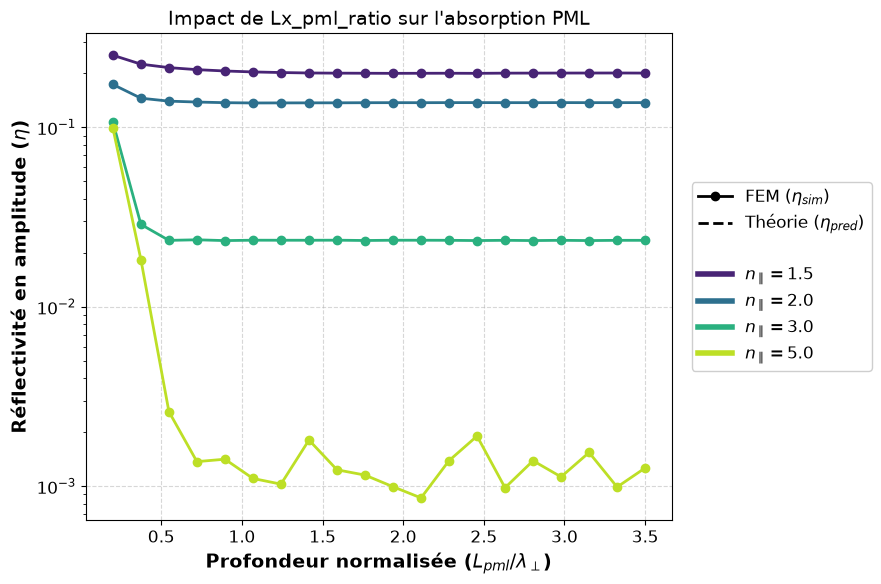

  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Resolution_PPW.png


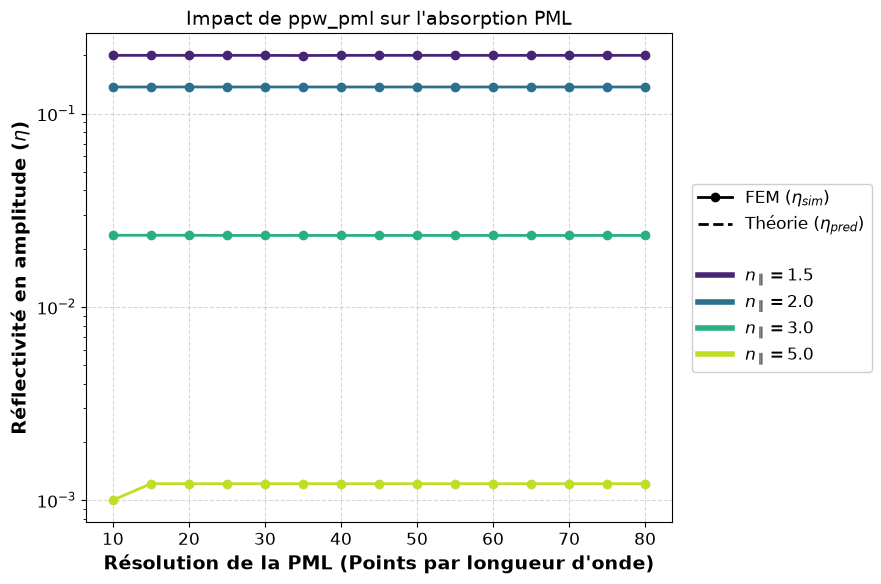

  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Sx_imag.png


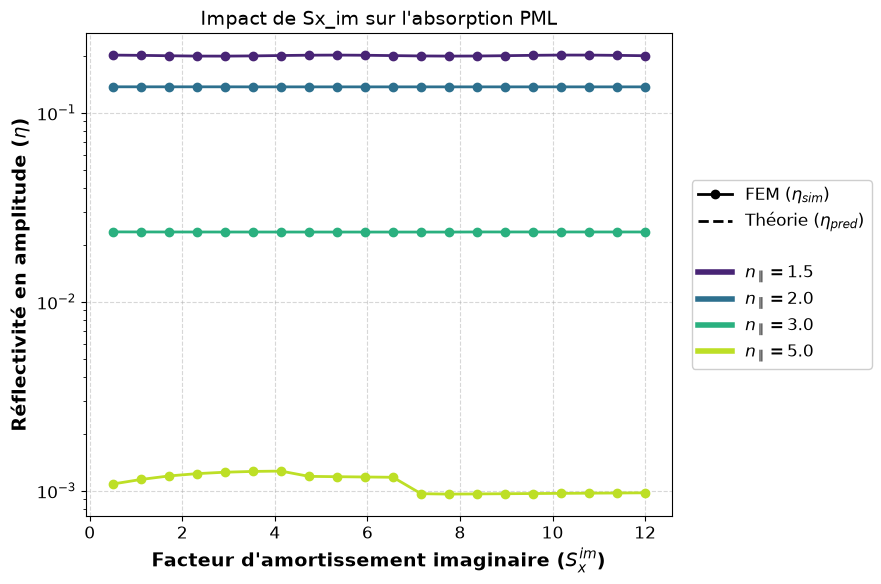

  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_Sx_real.png


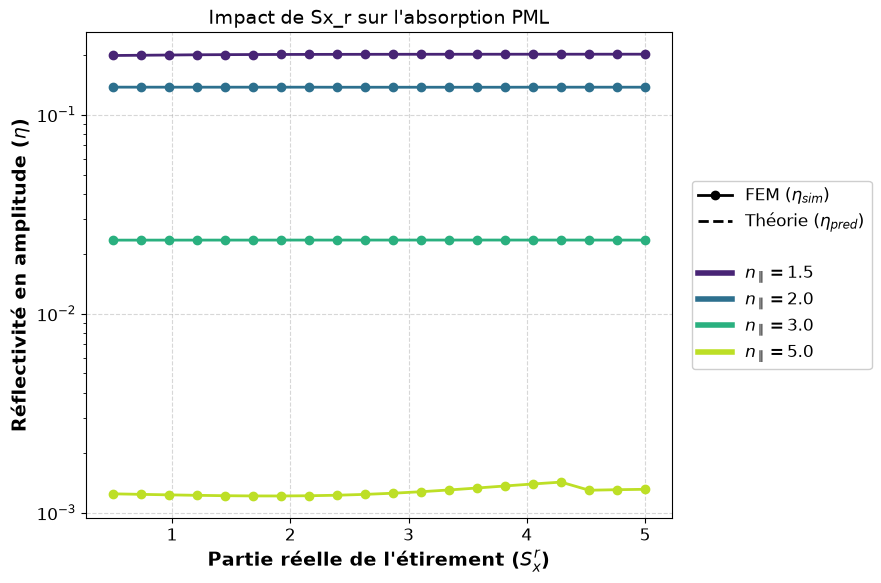

  -> Graphe sauvegardé : Analyse_Spectrale_Sweep_px.png


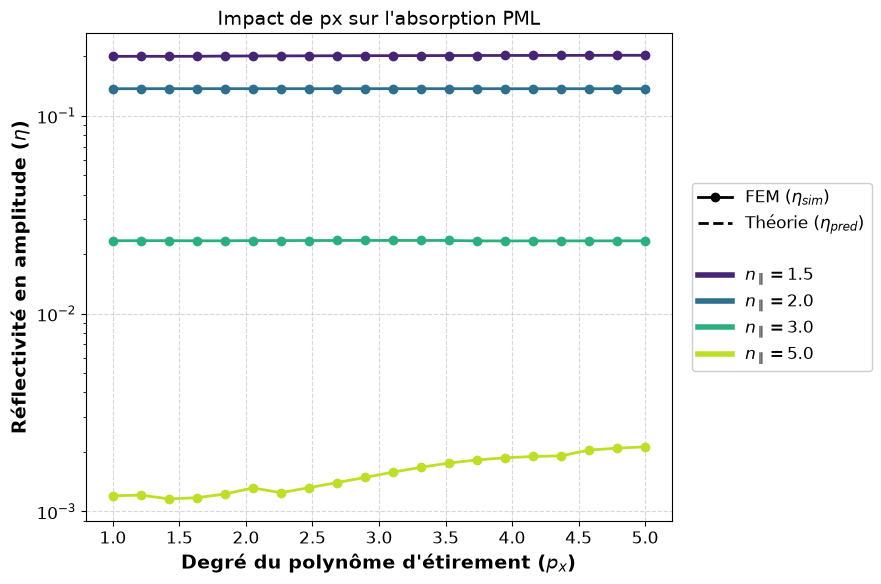

In [41]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==============================================================================
# CONFIGURATION GRAPHIQUE PROFESSIONNELLE
# ==============================================================================
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'figure.figsize': (9, 6),
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

# Dictionnaire pour avoir de beaux labels sur les axes X
FORMAT_LABELS = {
    'Sx_r': "Partie réelle de l'étirement ($S_x^r$)",
    'Sx_im': "Facteur d'amortissement imaginaire ($S_x^{im}$)",
    'px': "Degré du polynôme d'étirement ($p_x$)",
    'ppw_pml': "Résolution de la PML (Points par longueur d'onde)",
    'Lx_pml_ratio': "Profondeur normalisée ($L_{pml} / \lambda_\perp$)"
}

def plot_sweeps_all_npara(h5_filepath):
    """
    Parcourt tous les balayages d'un fichier HDF5 et trace eta_sim vs paramètre.
    Superpose les courbes pour tous les n_parallel sur le même graphique.
    """
    print(f"--- Création des graphiques multi-spectres depuis : {h5_filepath} ---")
    
    with h5py.File(h5_filepath, 'r') as h5f:
        
        # Trouver tous les groupes de balayage (Sweep_...)
        sweep_groups = [k for k in h5f.keys() if k.startswith('Sweep_')]
        
        for sweep_name in sweep_groups:
            grp = h5f[sweep_name]
            param_values = grp['param_values'][:]
            param_key = grp.attrs['param_name']
            
            # Identifier et trier les sous-groupes n_para
            n_para_keys = [k for k in grp.keys() if k.startswith('n_para_')]
            n_para_keys.sort(key=lambda x: float(x.split('_')[-1]))
            
            # Si le balayage a échoué ou est vide, on passe
            if not n_para_keys:
                continue
                
            fig, ax = plt.subplots()
            
            # Palette de couleurs pour différencier les n_para
            colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(n_para_keys)))
            
            for idx, n_key in enumerate(n_para_keys):
                n_para_val = float(n_key.split('_')[-1])
                subgrp = grp[n_key]
                
                eta_sim = subgrp['eta_sim'][:]
                eta_pred = subgrp['eta_pred'][:]
                
                # Tracé de la simulation (Ligne pleine + marqueurs)
                ax.plot(param_values, eta_sim, marker='o', linestyle='-', 
                        color=colors[idx], lw=2, markersize=6)
                
                # Tracé de la théorie (Ligne pointillée, légèrement transparente)
                # ax.plot(param_values, eta_pred, linestyle='--', 
                        #color=colors[idx], lw=2, alpha=0.7)

            # Mise en forme des axes
            ax.set_yscale('log')
            x_label = FORMAT_LABELS.get(param_key, param_key)
            ax.set_xlabel(x_label, fontweight='bold')
            ax.set_ylabel(r"Réflectivité en amplitude ($\eta$)", fontweight='bold')
            ax.set_title(f"Impact de {param_key} sur l'absorption PML")
            
            # ---------------------------------------------------------
            # CONSTRUCTION D'UNE LÉGENDE PERSONNALISÉE ET PROPRE
            # ---------------------------------------------------------
            legend_elements = []
            
            # 1. Éléments pour le type de donnée (Sim vs Théorie)
            legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='-', marker='o', label=r'FEM ($\eta_{sim}$)'))
            legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='--', label=r'Théorie ($\eta_{pred}$)'))
            
            # Espace vide invisible pour séparer les sections de la légende
            legend_elements.append(Line2D([0], [0], color='none', label=' '))
            
            # 2. Éléments pour les couleurs des n_para
            for idx, n_key in enumerate(n_para_keys):
                n_val = float(n_key.split('_')[-1])
                legend_elements.append(Line2D([0], [0], color=colors[idx], lw=4, label=rf'$n_\parallel = {n_val}$'))
                
            # Placement de la légende à l'extérieur du graphe pour ne pas cacher les courbes
            ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=0.95)
            
            plt.tight_layout()
            
            # Sauvegarde de l'image
            save_name = f"Analyse_Spectrale_{sweep_name}.png"
            plt.savefig(save_name, dpi=300, bbox_inches='tight')
            print(f"  -> Graphe sauvegardé : {save_name}")
            
            plt.show()

# ---> COMMANDE D'EXÉCUTION :
plot_sweeps_all_npara("Simulation_Results/PML_Radial_1D_Database_20260622_151022.h5")


In [ ]:
        # ----------------------------------------------------------------------
        # GRAPHE 2 : L'Effondrement Exponentiel (Profondeur L_pml)
        # ----------------------------------------------------------------------
        if 'Sweep_Lpml_Ratio' in h5f:
            grp = h5f['Sweep_Lpml_Ratio']
            param_values = grp['param_values'][:] # C'est le ratio L_pml / lambda_perp
            
            n_para_key = "n_para_2.0"
            if n_para_key in grp:
                subgrp = grp[n_para_key]
                eta_sim = subgrp['eta_sim'][:]
                eta_pred = subgrp['eta_pred'][:]
                
                fig2, ax2 = plt.subplots()
                ax2.scatter(param_values, eta_sim, marker="+", color="k", label=r'Théorie ($\eta_{pred}$)')
                # ax2.plot(param_values, eta_sim, 'bo-', label=r'FEM Simulation ($\eta_{sim}$)')
                
                ax2.set_yscale('log')
                ax2.set_xlabel(r"Profondeur normalisée de la PML ($L_{pml} / \lambda_\perp$)")
                ax2.set_ylabel(r"Coefficient de réflexion en amplitude ($\eta$)")
                ax2.set_title(r"Décroissance de la réflexion vs Profondeur PML")
                ax2.legend()
                plt.tight_layout()
                plt.savefig("Graphe2_Decroissance_Lpml.png", dpi=300)
                plt.show()

        # ----------------------------------------------------------------------
        # GRAPHE 3 : Le Lissage Spatial (Profil de Px selon p_x)
        # ----------------------------------------------------------------------
        if 'Sweep_px' in h5f:
            grp = h5f['Sweep_px']
            param_values = grp['param_values'][:]
            
            n_para_key = "n_para_2.0"
            if n_para_key in grp:
                subgrp = grp[n_para_key]
                Px_profiles = subgrp['Px_profiles'][:]
                x_depths = subgrp['x_normalized_depths'][:]
                
                fig3, ax3 = plt.subplots()
                # On choisit de tracer pour p_x environ égal à 1.0, 2.0 et 4.0
                target_px = [1.0, 2.0, 4.0]
                colors = ['crimson', 'forestgreen', 'navy']
                
                for target, color in zip(target_px, colors):
                    # Trouve l'index le plus proche dans param_values
                    idx = (np.abs(param_values - target)).argmin()
                    actual_px = param_values[idx]
                    
                    x_plot = x_depths[idx]
                    Px_plot = Px_profiles[idx]
                    
                    # On ignore les NaNs ou les profils qui ont échoué
                    if not np.isnan(Px_plot[0]):
                        ax3.plot(x_plot, Px_plot, color=color, lw=2.5, 
                                 label=f'$p_x = {actual_px:.1f}$')
                
                ax3.set_xlabel(r"Profondeur radiale normalisée ($x / \lambda_\perp$)")
                ax3.set_ylabel(r"Flux de puissance actif normalisé ($P_x / P_{x,0}$)")
                ax3.set_title(r"Profil d'absorption de l'énergie dans la PML")
                ax3.set_xlim(0, max(x_depths[0]))
                ax3.set_ylim(-0.05, 1.05)
                ax3.legend()
                plt.tight_layout()
                plt.savefig("Graphe3_Profil_Px.png", dpi=300)
                plt.show()

        # ----------------------------------------------------------------------
        # GRAPHE 4 : L'Universalité Spectrale (Erreur selon n_para)
        # ----------------------------------------------------------------------
        if 'Sweep_Sx_imag' in h5f:
            grp = h5f['Sweep_Sx_imag']
            param_values = grp['param_values'][:]
            
            fig4, ax4 = plt.subplots()
            colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(grp.keys())))
            
            # On boucle sur tous les n_para disponibles dans le HDF5
            n_para_keys = [k for k in grp.keys() if k.startswith('n_para_')]
            # Tri numérique pour une belle légende
            n_para_keys.sort(key=lambda x: float(x.split('_')[-1]))
            
            for idx, n_key in enumerate(n_para_keys):
                n_para_val = float(n_key.split('_')[-1])
                subgrp = grp[n_key]
                eta_sim = subgrp['eta_sim'][:]
                eta_pred = subgrp['eta_pred'][:]
                
                # Calcul de l'erreur relative |sim - pred| / pred
                # On masque les zéros stricts pour éviter les divisions par zéro
                valid = (eta_pred > 1e-12) & (~np.isnan(eta_sim))
                error = np.full_like(eta_sim, np.nan)
                error[valid] = np.abs(eta_sim[valid] - eta_pred[valid]) / eta_pred[valid]
                
                # On trace en pourcentage
                ax4.plot(param_values, error * 100.0, marker='o', linestyle='-', 
                         color=colors[idx], label=rf'$n_\parallel = {n_para_val}$')

            ax4.set_yscale('log')
            ax4.set_xlabel(r"Facteur d'amortissement imaginaire ($S_x^{im}$)")
            ax4.set_ylabel(r"Erreur relative PML $|\eta_{sim} - \eta_{pred}| / \eta_{pred}$ [%]")
            ax4.set_title(r"Robustesse de la PML face au spectre d'onde")
            ax4.legend(ncol=2)
            plt.tight_layout()
            plt.savefig("Graphe4_Universalite_npara.png", dpi=300)
            plt.show()

In [ ]:
import os
import copy
import h5py
import numpy as np
import datetime
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def generate_Toroidal_PML_database(base_cfg, save_dir="Simulation_Results"):
    """
    Exécute des balayages indépendants sur les paramètres de la PML Toroïdale.
    Utilise le mode FULL_2D et la symétrie de phase (+n_para et -n_para) 
    pour évaluer indépendamment la PML Droite et la PML Gauche.
    """
    print("=========================================================")
    print("  GÉNÉRATION DATABASE : PML TOROÏDALE GAUCHE & DROITE")
    print("=========================================================")
    
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    h5_filename = os.path.join(save_dir, f"PML_Toroidal_Database_{timestamp}.h5")
    
    # 1. Les paires de n_parallel pour tester la PML Droite (+) et Gauche (-)
    n_para_list = [2.0, -2.0, 4.0, -4.0]
    
    # 2. Définition des balayages indépendants
    # Format -> 'Nom_du_Groupe': (Valeurs_à_tester, 'clé_PML')
    scans = {
        'Sweep_Sz_real': (np.linspace(0.5, 5.0, 15), 'Sz_r'),
        'Sweep_Sz_imag': (np.linspace(0.5, 12.0, 15), 'Sz_im'),
        'Sweep_pz': (np.linspace(1.0, 5.0, 15), 'pz'),
        'Sweep_Resolution_PPW': (np.linspace(10.0, 80.0, 15), 'ppw_pml'),
        'Sweep_Lz_pml_Ratio': (np.linspace(0.5, 4.0, 20), 'Lz_pml_ratio')   # Lz_pml / lambda_para
    }
    
    with h5py.File(h5_filename, 'w') as h5f:
        h5f.attrs['Description'] = "Validation PML Toroïdale Droite (+n_//) et Gauche (-n_//) en FULL_2D"
        
        for group_name, (param_values, param_key) in scans.items():
            print(f"\n---> Lancement du balayage : {group_name} ({param_key})")
            grp = h5f.create_group(group_name)
            grp.attrs['param_name'] = param_key
            grp.create_dataset('param_values', data=param_values)
            
            for n_para_val in n_para_list:
                side = "DROITE" if n_para_val > 0 else "GAUCHE"
                print(f"  >> Test PML {side} (n_para = {n_para_val})")
                subgrp = grp.create_group(f"n_para_{n_para_val}")
                
                eta_sim_list, eta_pred_list = [], []
                
                for val in param_values:
                    # --- FIX: SAFE DEEPCOPY ---
                    # On ne copie que les dictionnaires purs (WAVE, DOMAIN, PML, etc.)
                    # et on ignore les modules importés (math, ngsolve) ou les variables système (__name__)
                    scan_cfg = {}
                    for key, value in base_cfg.items():
                        if isinstance(value, dict) and not key.startswith('__'):
                            scan_cfg[key] = copy.deepcopy(value)
                            
                    scan_cfg['WAVE']['n_para'] = n_para_val
                    
                    # Injection du paramètre
                    if param_key in ['Sz_r', 'Sz_im', 'pz', 'ppw_pml']:
                        scan_cfg['PML'][param_key] = val
                    elif param_key == 'Lz_pml_ratio':
                        # Lz_pml_ratio * lambda_para (longueur d'onde toroïdale)
                        c0, freq = scan_cfg['CONST']['c0'], scan_cfg['WAVE']['freq_LH']
                        lambda_para = (c0 / freq) / np.abs(n_para_val)
                        scan_cfg['DOMAIN']['Lz_pml'] = val * lambda_para
                        scan_cfg['DOMAIN']['Lz_tot'] = scan_cfg['DOMAIN']['Lz_plasma'] + 2.0 * scan_cfg['DOMAIN']['Lz_pml']

                    try:
                        # RIGOUREUX : On utilise FULL_2D sans antenne (onde plane analytique avec angle)
                        solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="FULL_2D", antenna_grill=None)
                        solver.build_physics_Stix_B_field()
                        mesh = solver.build_mesh_with_PMLs()
                        
                        _, _, _, _, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode="FULL_2D")
                        
                        eta_sim_list.append(diag_data['eta_sim_T'])
                        eta_pred_list.append(diag_data['eta_pred_T'])
                        
                    except Exception as e:
                        print(f"     [!] Echec pour {param_key}={val:.3f} : {e}")
                        eta_sim_list.append(np.nan)
                        eta_pred_list.append(np.nan)
                
                # Sauvegarde des courbes de réflectivité
                subgrp.create_dataset('eta_sim_T', data=eta_sim_list)
                subgrp.create_dataset('eta_pred_T', data=eta_pred_list)
                    
    print(f"\n[SUCCÈS] Base de données HDF5 générée : {h5_filename}")
    return h5_filename

# ---> LIGNE POUR DÉMARRER LA GÉNÉRATION (À décommenter) :
db_filepath_T = generate_Toroidal_PML_database(cfg.__dict__, save_dir="Simulation_Results")

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.figsize': (9, 6),
    'lines.linewidth': 2,
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linestyle': '--'
})

def plot_Toroidal_PML_diagnostics(h5_filepath):
    """
    Lit la base de données HDF5 Toroïdale et génère les graphes de validation.
    Superpose les résultats pour +n_para (PML Droite) et -n_para (PML Gauche) 
    pour prouver leur parfaite équivalence.
    """
    print(f"--- Lecture de la Database Toroïdale : {h5_filepath} ---")
    
    with h5py.File(h5_filepath, 'r') as h5f:
        
        # ----------------------------------------------------------------------
        # GRAPHE 1 : Le "Sweet Spot" Numérique (Sz_im) - PREUVE DE SYMÉTRIE
        # ----------------------------------------------------------------------
        if 'Sweep_Sz_imag' in h5f:
            grp = h5f['Sweep_Sz_imag']
            param_values = grp['param_values'][:]
            
            # On extrait les paires symétriques
            key_right = "n_para_2.0"
            key_left = "n_para_-2.0"
            
            if key_right in grp and key_left in grp:
                eta_sim_R = grp[key_right]['eta_sim_T'][:]
                eta_pred_R = grp[key_right]['eta_pred_T'][:]
                
                eta_sim_L = grp[key_left]['eta_sim_T'][:]
                # La théorie est identique en valeur absolue
                
                fig1, ax1 = plt.subplots()
                
                # Tracé de la théorie (Ligne noire pointillée)
                ax1.plot(param_values, eta_pred_R, 'k--', lw=2.5, zorder=2, 
                         label=r'Théorie Jacquot ($\eta_{pred\_T}$)')
                
                # Tracé de la PML Droite (+2.0) avec des ronds rouges
                ax1.plot(param_values, eta_sim_R, marker='o', color='crimson', 
                         linestyle='-', markersize=8, zorder=3, alpha=0.8,
                         label=r'PML Droite ($n_\parallel = +2.0$)')
                
                # Tracé de la PML Gauche (-2.0) avec des croix bleues
                ax1.plot(param_values, eta_sim_L, marker='x', color='navy', 
                         linestyle='None', markeredgewidth=2.5, markersize=10, zorder=4,
                         label=r'PML Gauche ($n_\parallel = -2.0$)')
                
                ax1.set_yscale('log')
                ax1.set_xlabel(r"Facteur d'amortissement imaginaire toroïdal ($S_z^{im}$)")
                ax1.set_ylabel(r"Coefficient de réflexion en amplitude ($\eta_T$)")
                ax1.set_title(r"Équivalence des PMLs Toroïdales (Optimisation $S_z^{im}$)")
                ax1.legend(framealpha=0.95, edgecolor='black')
                plt.tight_layout()
                plt.savefig("Graphe1_Toroidal_SweetSpot_Symetrie.png", dpi=300)
                plt.show()

        # ----------------------------------------------------------------------
        # GRAPHE 2 : L'Effondrement Exponentiel (Profondeur Lz_pml)
        # ----------------------------------------------------------------------
        if 'Sweep_Lz_pml_Ratio' in h5f:
            grp = h5f['Sweep_Lz_pml_Ratio']
            param_values = grp['param_values'][:] # Ratio Lz_pml / lambda_para
            
            key_right = "n_para_2.0"
            key_left = "n_para_-2.0"
            
            if key_right in grp and key_left in grp:
                eta_sim_R = grp[key_right]['eta_sim_T'][:]
                eta_pred_R = grp[key_right]['eta_pred_T'][:]
                eta_sim_L = grp[key_left]['eta_sim_T'][:]
                
                fig2, ax2 = plt.subplots()
                
                ax2.plot(param_values, eta_pred_R, 'k--', lw=2.5, label=r'Théorie ($\eta_{pred\_T}$)')
                ax2.plot(param_values, eta_sim_R, 'ro-', alpha=0.8, label=r'PML Droite (+)')
                ax2.plot(param_values, eta_sim_L, 'bx', markeredgewidth=2.5, markersize=9, label=r'PML Gauche (-)')
                
                ax2.set_yscale('log')
                ax2.set_xlabel(r"Profondeur normalisée de la PML ($L_{z, pml} / \lambda_\parallel$)")
                ax2.set_ylabel(r"Coefficient de réflexion en amplitude ($\eta_T$)")
                ax2.set_title(r"Décroissance de la réflexion vs Profondeur Toroïdale")
                ax2.legend(framealpha=0.95, edgecolor='black')
                plt.tight_layout()
                plt.savefig("Graphe2_Toroidal_Decroissance_Lzpml.png", dpi=300)
                plt.show()

        # ----------------------------------------------------------------------
        # GRAPHE 3 : L'Universalité Spectrale Toroïdale (Erreur selon n_para)
        # ----------------------------------------------------------------------
        if 'Sweep_Sz_imag' in h5f:
            grp = h5f['Sweep_Sz_imag']
            param_values = grp['param_values'][:]
            
            fig3, ax3 = plt.subplots()
            
            # On boucle sur tous les n_para (positifs ET négatifs)
            n_para_keys = [k for k in grp.keys() if k.startswith('n_para_')]
            n_para_keys.sort(key=lambda x: float(x.split('_')[-1]))
            
            colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(n_para_keys)))
            
            for idx, n_key in enumerate(n_para_keys):
                n_para_val = float(n_key.split('_')[-1])
                subgrp = grp[n_key]
                eta_sim = subgrp['eta_sim_T'][:]
                eta_pred = subgrp['eta_pred_T'][:]
                
                valid = (eta_pred > 1e-12) & (~np.isnan(eta_sim))
                error = np.full_like(eta_sim, np.nan)
                error[valid] = np.abs(eta_sim[valid] - eta_pred[valid]) / eta_pred[valid]
                
                # Style de ligne selon Droite (+) ou Gauche (-)
                marker_style = 'o' if n_para_val > 0 else 's'
                line_style = '-' if n_para_val > 0 else '--'
                
                ax3.plot(param_values, error * 100.0, marker=marker_style, linestyle=line_style, 
                         color=colors[idx], lw=2, label=rf'$n_\parallel = {n_para_val}$')

            ax3.set_yscale('log')
            ax3.set_xlabel(r"Facteur d'amortissement imaginaire toroïdal ($S_z^{im}$)")
            ax3.set_ylabel(r"Erreur relative $|\eta_{sim} - \eta_{pred}| / \eta_{pred}$ [%]")
            ax3.set_title(r"Robustesse des PMLs Toroïdales face au spectre d'onde")
            ax3.legend(ncol=2, framealpha=0.95, edgecolor='black')
            plt.tight_layout()
            plt.savefig("Graphe3_Toroidal_Universalite_npara.png", dpi=300)
            plt.show()

# ---> POUR EXÉCUTER :
# Remplacez le nom du fichier par celui qui a été généré pour les PMLs Toroïdales
# plot_Toroidal_PML_diagnostics("Simulation_Results/PML_Toroidal_Database_20260622_XXXXXX.h5")